In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('fruits.csv')
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [3]:
df.shape

(40, 3)

In [4]:
df.ndim

2

In [5]:
df.isna().sum()

Weight    0
Size      0
Class     0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [8]:
df.columns

Index(['Weight', 'Size', 'Class'], dtype='object')

In [9]:
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [10]:
# Applying the Lable Encoding for the y variable so that I can predict the binary classification
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.Class = le.fit_transform(df['Class'])

In [11]:
df.head()

,Weight,Size,Class
0,69,4.39,1
1,69,4.21,1
2,65,4.09,1
3,72,5.85,0
4,67,4.70,1


# Orange has converted to 1 and apple are converted to 0

In [12]:
# Applying the train test split in the dataset
x = df.iloc[:,0:2]
y = df.Class

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1,shuffle=True)

In [13]:
x_train.shape

(32, 2)

In [14]:
x_test.shape

(8, 2)

In [15]:
# Building the Decision Tree Classifier model in the train test dataset
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [16]:
print(f'Accuracy of the training dataset: {dtc.score(x_train,y_train)}')
print(f'Accuracy of the testing dataset: {dtc.score(x_test,y_test)}')

Accuracy of the training dataset: 1.0
Accuracy of the testing dataset: 1.0


In [18]:
df.columns

Index(['Weight', 'Size', 'Class'], dtype='object')

[Text(0.5, 0.75, 'Size <= 4.97\ngini = 0.498\nsamples = 32\nvalue = [17, 15]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.625, 0.5, '  False')]

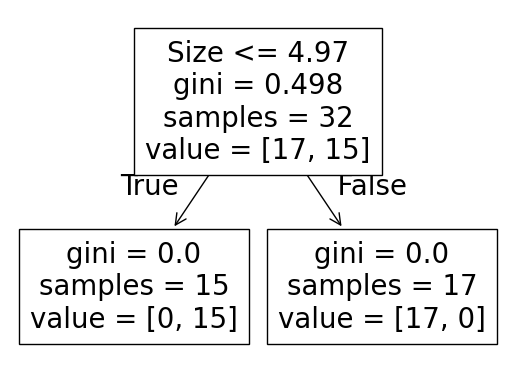

In [19]:
from sklearn.tree import plot_tree
plot_tree(dtc,feature_names=['Weight','Size'])

In [21]:
from sklearn.tree import export_text
rules = export_text(dtc, feature_names=['Weight','Size'])
print(rules)

|--- Size <= 4.97
|   |--- class: 1
|--- Size >  4.97
|   |--- class: 0



In [22]:
from sklearn.tree import DecisionTreeClassifier
dtc1 = DecisionTreeClassifier(criterion='entropy')
dtc1.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

[Text(0.5, 0.75, 'Weight <= 69.5\nentropy = 0.997\nsamples = 32\nvalue = [17, 15]'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.625, 0.5, '  False')]

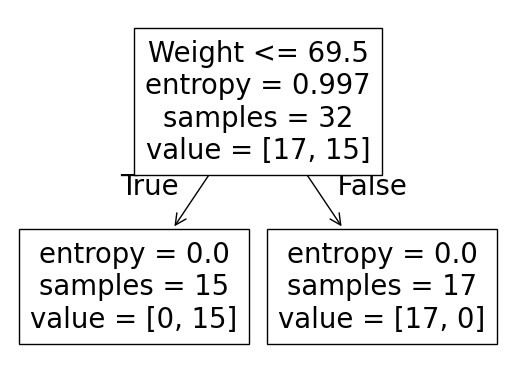

In [23]:
from sklearn.tree import plot_tree
plot_tree(dtc1, feature_names=['Weight','Size'])

In [25]:
print(f'This is the accuracy score for training dataset while applying entropy: {dtc1.score(x_train,y_train)}')
print(f'This is the accuracy score for testing dataset while applying entropy: {dtc1.score(x_test,y_test)}')

This is the accuracy score for training dataset while applying entropy: 1.0
This is the accuracy score for testing dataset while applying entropy: 0.75


In [27]:
from sklearn.tree import export_text
rule = export_text(dtc1, feature_names=['Weight','Size'])
print(rule)

|--- Weight <= 69.50
|   |--- class: 1
|--- Weight >  69.50
|   |--- class: 0



In [28]:
import pickle
with open('decision_tree_model.pkl','wb') as file:
    pickle.dump(dtc1,file)